In [ ]:
# STEP 1: Import Libraries
import os, cv2, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
warnings.filterwarnings("ignore")
print("All libraries imported successfully!")
print(f"TensorFlow : {tf.__version__}")
print(f"OpenCV     : {cv2.__version__}")
print(f"NumPy      : {np.__version__}")


All libraries imported successfully!
TensorFlow : 2.20.0
OpenCV     : 4.13.0
NumPy      : 2.0.2


In [ ]:
# STEP 2: Download Dataset from Kaggle
# You need a Kaggle account. Get API key from kaggle.com -> Account -> Create API Token
import kagglehub
dataset_path = kagglehub.dataset_download("bmadushanirodrigo/fracture-multi-region-x-ray-data")
print(f"Dataset downloaded to: {dataset_path}")


100%|██████████| 481M/481M [00:04<00:00, 109MB/s] 

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data/versions/2


In [ ]:
# STEP 3: Explore Dataset Structure
def find_data_root(base):
    for root, dirs, _ in os.walk(base):
        if "train" in [d.lower() for d in dirs]:
            return root
    return base

DATA_ROOT = find_data_root(dataset_path)
print(f"Data root: {DATA_ROOT}\n")
for split in ["train", "val", "test"]:
    split_dir = os.path.join(DATA_ROOT, split)
    if os.path.isdir(split_dir):
        for cls in sorted(os.listdir(split_dir)):
            cls_path = os.path.join(split_dir, cls)
            if os.path.isdir(cls_path):
                print(f"  {split:6s} / {cls:20s} -> {len(os.listdir(cls_path))} images")


Data root: /root/.cache/kagglehub/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data/versions/2/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification

  train  / fractured            -> 4606 images
  train  / not fractured        -> 4640 images
  val    / fractured            -> 337 images
  val    / not fractured        -> 492 images
  test   / fractured            -> 238 images
  test   / not fractured        -> 268 images


In [ ]:
# STEP 4: Load & Prepare Dataset (RGB, shared across all 3 models)
# VGG16 / ResNet50 require 3-channel input, so we load everything as RGB
# and keep IMG_SIZE small (150x150) to keep training fast on Colab.
IMG_SIZE = 128

def load_images_from_folder(folder, img_size=IMG_SIZE):
    images, labels = [], []
    for cls_name in sorted(os.listdir(folder)):
        cls_path = os.path.join(folder, cls_name)
        if not os.path.isdir(cls_path):
            continue
        label = 0 if "not" in cls_name.lower() else 1  # 0=Normal, 1=Fractured
        for fname in os.listdir(cls_path):
            try:
                img = cv2.imread(os.path.join(cls_path, fname), cv2.IMREAD_COLOR)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    images.append(cv2.resize(img, (img_size, img_size)))
                    labels.append(label)
            except Exception:
                continue
    return np.array(images), np.array(labels)

X_train_raw, y_train = load_images_from_folder(os.path.join(DATA_ROOT, "train"))
X_val_raw, y_val     = load_images_from_folder(os.path.join(DATA_ROOT, "val"))
X_test_raw, y_test   = load_images_from_folder(os.path.join(DATA_ROOT, "test"))

print(f"Training   : {X_train_raw.shape[0]} images  shape: {X_train_raw.shape}")
print(f"Validation : {X_val_raw.shape[0]} images  shape: {X_val_raw.shape}")
print(f"Test       : {X_test_raw.shape[0]} images  shape: {X_test_raw.shape}")

# Plain [0,1] scaled version -> used by the custom CNN (trained from scratch)
X_train_cnn = X_train_raw.astype("float32") / 255.0
X_val_cnn   = X_val_raw.astype("float32") / 255.0
X_test_cnn  = X_test_raw.astype("float32") / 255.0


Training   : 9246 images  shape: (9246, 128, 128, 3)
Validation : 829 images  shape: (829, 128, 128, 3)
Test       : 506 images  shape: (506, 128, 128, 3)


### Why different preprocessing per model?
The custom CNN is trained from scratch, so a simple `/255.0` scale is fine.
VGG16 and ResNet50, however, were pretrained on ImageNet with their own specific
normalization (channel-wise mean subtraction). We must use each model's own
`preprocess_input` function or the pretrained weights will see the wrong input
distribution and transfer learning will perform badly.

In [ ]:
# STEP 5: Model 1 - Custom CNN (trained from scratch)
cnn_model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
], name="Custom_CNN")
cnn_model.summary()


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# STEP 6: Compile & Train Custom CNN
cnn_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
early_stop = EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)

print("Training Custom CNN...\n")
cnn_history = cnn_model.fit(
    X_train_cnn, y_train, epochs=20, batch_size=8,
    validation_data=(X_val_cnn, y_val), callbacks=[early_stop], verbose=1
)
print("\nCustom CNN training complete!")


Training Custom CNN...

Epoch 1/20
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.8531 - loss: 0.3302 - val_accuracy: 0.9156 - val_loss: 0.2353
Epoch 2/20
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9731 - loss: 0.0824 - val_accuracy: 0.9590 - val_loss: 0.1297
Epoch 3/20
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9844 - loss: 0.0426 - val_accuracy: 0.9542 - val_loss: 0.1699
Epoch 4/20
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9888 - loss: 0.0347 - val_accuracy: 0.9650 - val_loss: 0.1092
Epoch 5/20
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9900 - loss: 0.0260 - val_accuracy: 0.9602 - val_loss: 0.1313
Epoch 6/20
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9930 - loss: 0.0204 - val_accuracy: 0.9747 - val_loss: 0.0739
Epoch 7/20
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9939 - loss: 0.0200 - val_accuracy: 0.9662 - val_loss: 0.1259
Epoch 8/20
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy

In [ ]:
import gc
import tensorflow as tf

# Free CNN dataset memory
del X_train_cnn
del X_val_cnn
del X_test_cnn

gc.collect()
tf.keras.backend.clear_session()

print("Memory cleared successfully!")

Memory cleared successfully!


In [ ]:
X_train_vgg = vgg16_preprocess(X_train_raw.astype(np.float32))
X_val_vgg   = vgg16_preprocess(X_val_raw.astype(np.float32))
X_test_vgg  = vgg16_preprocess(X_test_raw.astype(np.float32))

vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

vgg_base.trainable = True

for layer in vgg_base.layers[:-10]:
    layer.trainable = False
vgg_model = keras.Sequential([
    vgg_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

In [ ]:
vgg_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

vgg_history = vgg_model.fit(
    X_train_vgg,
    y_train,
    epochs=20,
    batch_size=8,
    validation_data=(X_val_vgg, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 96s 74ms/step - accuracy: 0.9056 - loss: 0.2466 - val_accuracy: 0.9771 - val_loss: 0.0651
Epoch 2/20
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 77s 66ms/step - accuracy: 0.9925 - loss: 0.0225 - val_accuracy: 0.9903 - val_loss: 0.0297
Epoch 3/20
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 76s 66ms/step - accuracy: 0.9931 - loss: 0.0211 - val_accuracy: 0.9783 - val_loss: 0.0500
Epoch 4/20
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 76s 66ms/step - accuracy: 0.9992 - loss: 0.0034 - val_accuracy: 0.9928 - val_loss: 0.0227
Epoch 5/20
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 76s 66ms/step - accuracy: 0.9938 - loss: 0.0159 - val_accuracy: 0.9916 - val_loss: 0.0207
Epoch 6/20
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 77s 66ms/step - accuracy: 0.9964 - loss: 0.0087 - val_accuracy: 1.0000 - val_loss: 0.0035
Epoch 7/20
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 76s 66ms/step - accuracy: 0.9948 - loss: 0.0165 - val_accuracy: 1.0000 - val_loss: 0.0028
Epoch 8/20
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 75s 65ms/step - accuracy: 0.9995 -

In [ ]:
import gc
import tensorflow as tf

# Delete only VGG datasets
del X_train_vgg
del X_val_vgg
del X_test_vgg

gc.collect()
tf.keras.backend.clear_session()

print("VGG16 dataset memory cleared!")

VGG16 dataset memory cleared!


In [ ]:
# STEP 9: Model 3 - ResNet50 (Transfer Learning)
X_train_res = resnet50_preprocess(X_train_raw.astype("float32").copy())
X_val_res   = resnet50_preprocess(X_val_raw.astype("float32").copy())
X_test_res  = resnet50_preprocess(X_test_raw.astype("float32").copy())

resnet_base = ResNet50(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
resnet_base.trainable = True

for layer in resnet_base.layers[:-20]:
    layer.trainable = False
resnet_model = keras.Sequential([
    resnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
], name="ResNet50_Transfer")
resnet_model.summary()


Model: "ResNet50_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 9,193,729 (35.07 MB)

 Non-trainable params: 14,656,384 (55.91 MB)

In [ ]:
# STEP 10: Compile & Train ResNet50
resnet_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),
                      loss="binary_crossentropy", metrics=["accuracy"])

print("Training ResNet50 (frozen base, only the new head learns)...\n")
resnet_history = resnet_model.fit(
    X_train_res,
    y_train,
    epochs=20,
    batch_size=8,   # Changed from 32 to 8
    validation_data=(X_val_res, y_val),
    callbacks=[early_stop],
    verbose=1
)
print("\nResNet50 training complete!")


Training ResNet50 (frozen base, only the new head learns)...

Epoch 1/20
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.8345 - loss: 0.3695 - val_accuracy: 0.9638 - val_loss: 0.1090
Epoch 2/20
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 30s 26ms/step - accuracy: 0.9762 - loss: 0.0791 - val_accuracy: 0.9819 - val_loss: 0.0570
Epoch 3/20
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 29s 25ms/step - accuracy: 0.9895 - loss: 0.0380 - val_accuracy: 0.9903 - val_loss: 0.0355
Epoch 4/20
1156/1156 ━━━━━━━━━━━━━━━━━━━━ 29s 25ms/step - accuracy: 0.9933 - loss: 0.0230 - val_accuracy: 0.9988 - val_loss: 0.0133

ResNet50 training complete!


In [ ]:
import gc

del X_train_res
del X_val_res
del X_test_res

gc.collect()

print("ResNet dataset cleared")

ResNet dataset cleared


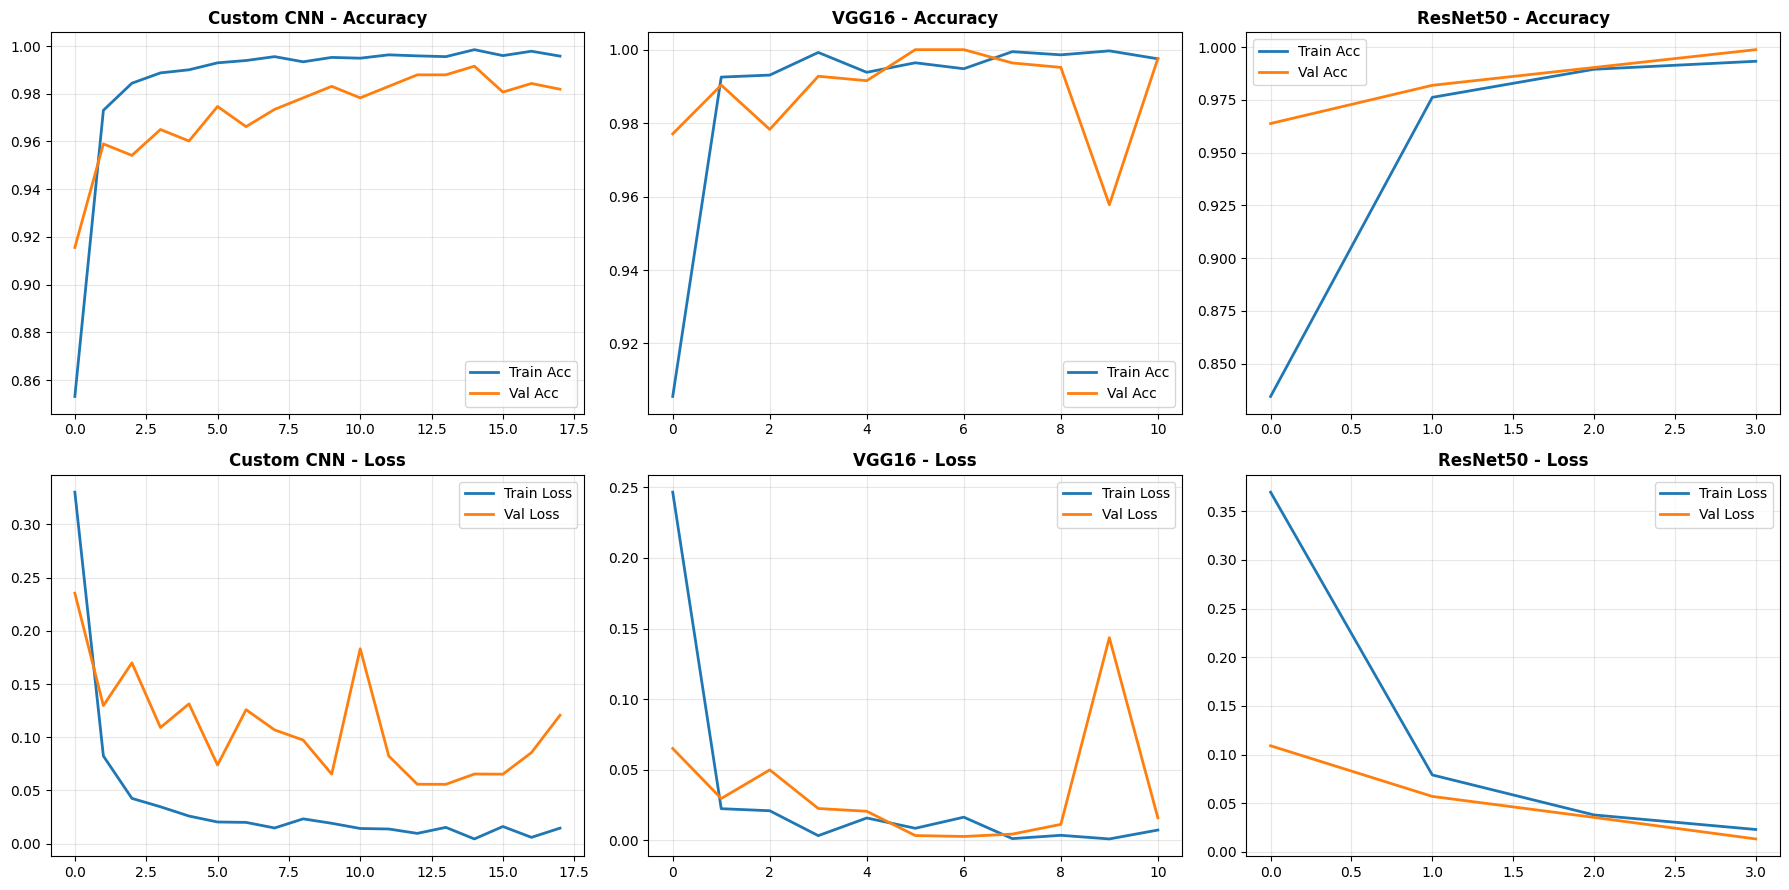

In [ ]:
# STEP 11: Plot Training Curves for All 3 Models
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
histories = [("Custom CNN", cnn_history), ("VGG16", vgg_history), ("ResNet50", resnet_history)]

for col, (name, hist) in enumerate(histories):
    axes[0, col].plot(hist.history["accuracy"], label="Train Acc", linewidth=2)
    axes[0, col].plot(hist.history["val_accuracy"], label="Val Acc", linewidth=2)
    axes[0, col].set_title(f"{name} - Accuracy", fontweight="bold")
    axes[0, col].legend(); axes[0, col].grid(True, alpha=0.3)

    axes[1, col].plot(hist.history["loss"], label="Train Loss", linewidth=2)
    axes[1, col].plot(hist.history["val_loss"], label="Val Loss", linewidth=2)
    axes[1, col].set_title(f"{name} - Loss", fontweight="bold")
    axes[1, col].legend(); axes[1, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# STEP 12: Evaluate & Compare All 3 Models on Test Set

# Recreate test datasets (they were deleted to save RAM)
X_test_cnn = X_test_raw.astype("float32") / 255.0
X_test_vgg = vgg16_preprocess(X_test_raw.astype("float32"))
X_test_res = resnet50_preprocess(X_test_raw.astype("float32"))

def evaluate_model(model, X_test, y_test, name):
    y_pred_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "y_pred": y_pred
    }

results = [
    evaluate_model(cnn_model, X_test_cnn, y_test, "Custom CNN"),
    evaluate_model(vgg_model, X_test_vgg, y_test, "VGG16"),
    evaluate_model(resnet_model, X_test_res, y_test, "ResNet50")
]

results_df = pd.DataFrame(results).drop(columns=["y_pred"])
print(results_df)

        Model  Accuracy  Precision    Recall  F1-Score
0  Custom CNN  0.990119   0.995745  0.983193  0.989429
1       VGG16  1.000000   1.000000  1.000000  1.000000
2    ResNet50  0.958498   0.939271  0.974790  0.956701


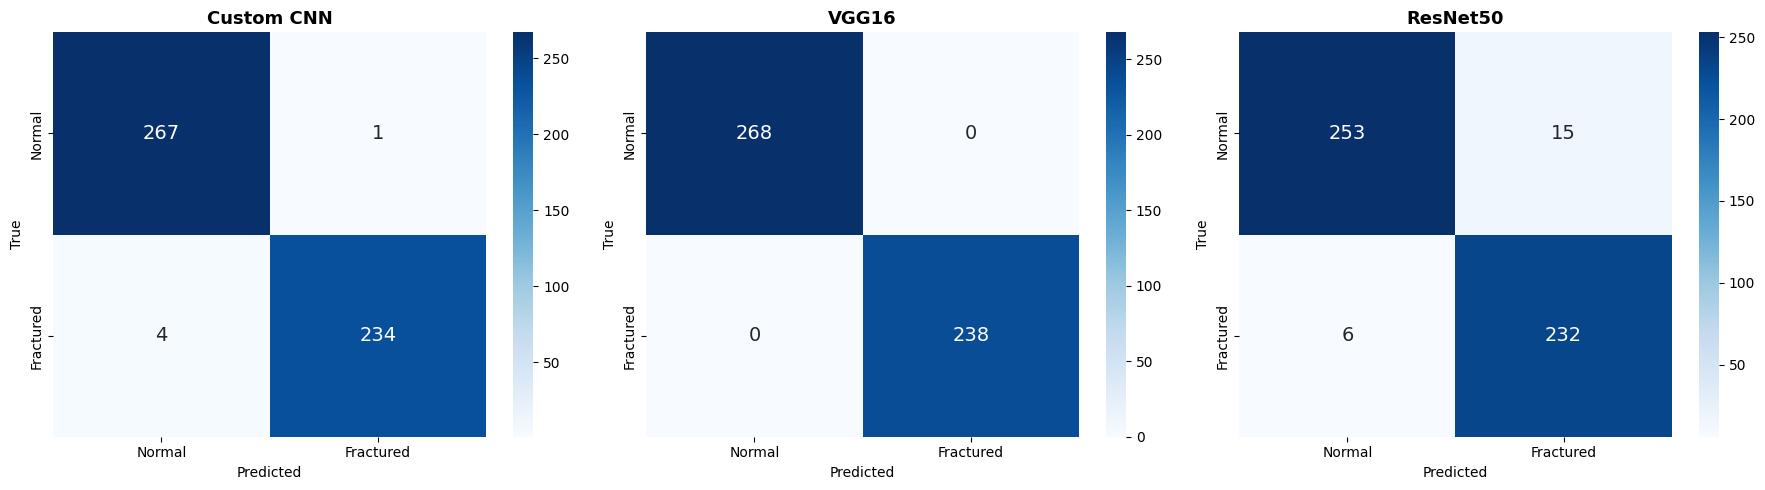

Custom CNN   -> TN:267  FP:1  FN:4 (missed fractures)  TP:234
VGG16        -> TN:268  FP:0  FN:0 (missed fractures)  TP:238
ResNet50     -> TN:253  FP:15  FN:6 (missed fractures)  TP:232


In [ ]:
# STEP 13: Confusion Matrices - Side by Side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, res in zip(axes, results):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal","Fractured"], yticklabels=["Normal","Fractured"],
                annot_kws={"size":14})
    ax.set_title(res["Model"], fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.show()

for res in results:
    tn, fp, fn, tp = confusion_matrix(y_test, res["y_pred"]).ravel()
    print(f"{res['Model']:12s} -> TN:{tn}  FP:{fp}  FN:{fn} (missed fractures)  TP:{tp}")


### 🏥 Which model should you trust most?
For a medical screening task, **Recall** (catching real fractures, i.e. minimizing FN)
matters more than raw Accuracy. Compare the FN column above across the three models -
the model with the fewest missed fractures is the safer choice, even if its overall
accuracy is very slightly lower than another model.

Upload an X-ray image (JPG / PNG):



Saving 1-rotated3-rotated2-rotated3.jpg to 1-rotated3-rotated2-rotated3 (1).jpg


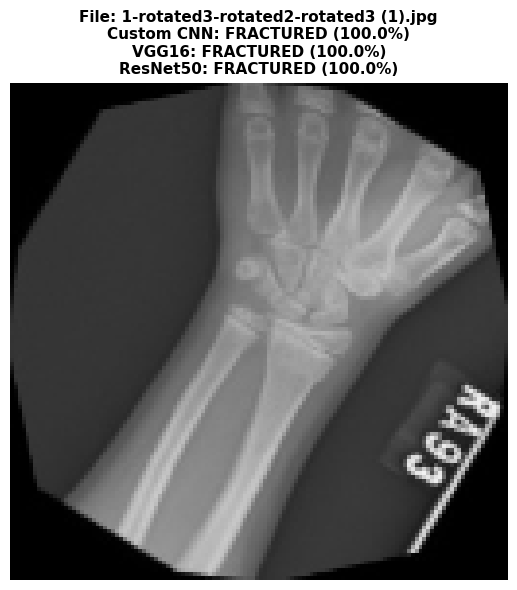


--- Predictions for 1-rotated3-rotated2-rotated3 (1).jpg ---
  Custom CNN   -> FRACTURED  (confidence: 100.00%)
  VGG16        -> FRACTURED  (confidence: 100.00%)
  ResNet50     -> FRACTURED  (confidence: 99.99%)


In [ ]:
# STEP 14: Upload & Predict with ALL 3 Models (Colab only)
from google.colab import files as colab_files

def prepare_input(img_resized):
    """Returns 3 differently-preprocessed versions of the same image, one per model."""
    base = img_resized.astype("float32").reshape(1, IMG_SIZE, IMG_SIZE, 3)
    cnn_in    = base.copy() / 255.0
    vgg_in    = vgg16_preprocess(base.copy())
    resnet_in = resnet50_preprocess(base.copy())
    return cnn_in, vgg_in, resnet_in

print("Upload an X-ray image (JPG / PNG):\n")
uploaded = colab_files.upload()

for filename in uploaded:
    file_bytes = np.frombuffer(uploaded[filename], dtype=np.uint8)
    img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
    if img is None:
        print(f"Could not read {filename}")
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    cnn_in, vgg_in, resnet_in = prepare_input(img_resized)

    preds = {
        "Custom CNN": cnn_model.predict(cnn_in, verbose=0)[0][0],
        "VGG16":      vgg_model.predict(vgg_in, verbose=0)[0][0],
        "ResNet50":   resnet_model.predict(resnet_in, verbose=0)[0][0],
    }

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img_resized)
    ax.axis("off")

    title_lines = [f"File: {filename}"]
    for name, prob in preds.items():
        label = "FRACTURED" if prob > 0.5 else "NORMAL"
        conf = prob if prob > 0.5 else 1 - prob
        title_lines.append(f"{name}: {label} ({conf:.1%})")
    ax.set_title("\n".join(title_lines), fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"\n--- Predictions for {filename} ---")
    for name, prob in preds.items():
        label = "FRACTURED" if prob > 0.5 else "NORMAL"
        conf = prob if prob > 0.5 else 1 - prob
        print(f"  {name:12s} -> {label:10s} (confidence: {conf:.2%})")
